In [88]:
# 1) Imports & environment setup
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

# sklearn imports used across tasks
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix


# Reproducibility and plotting style
np.random.seed(42)
sns.set(style='whitegrid')
%matplotlib inline


#### Note: core imports

Core Python libraries are imported.

## 2) Load dataset into `df`

We load the raw dataset `data/customer_supermarket.csv` and inspect it.

In [89]:
# load raw dataset
df = pd.read_csv('data/customer_supermarket.csv', sep='\t', index_col=0, decimal=',')

# quick inspection
print('Rows, Columns:', df.shape)
df.head()

Rows, Columns: (471910, 8)


,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
0,536365,01/12/10 08:26,2.55,17850.0,United Kingdom,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,01/12/10 08:26,3.39,17850.0,United Kingdom,71053,WHITE METAL LANTERN,6
2,536365,01/12/10 08:26,2.75,17850.0,United Kingdom,84406B,CREAM CUPID HEARTS COAT HANGER,8
3,536365,01/12/10 08:26,3.39,17850.0,United Kingdom,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,01/12/10 08:26,3.39,17850.0,United Kingdom,84029E,RED WOOLLY HOTTIE WHITE HEART.,6


#### Note: data load

This cell reads the raw transaction table into `df` and prints its shape and head so you can confirm the file parsed correctly (separator and decimal settings). Use these outputs to verify expected columns and sample records before cleaning.

In [90]:
# info and basic stats
print('\nDataframe info:')
df.info()

print('\nNull counts by column:')
print(df.isnull().sum())


Dataframe info:
<class 'pandas.core.frame.DataFrame'>
Index: 471910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   BasketID         471910 non-null  object 
 1   BasketDate       471910 non-null  object 
 2   Sale             471910 non-null  float64
 3   CustomerID       406830 non-null  object 
 4   CustomerCountry  471910 non-null  object 
 5   ProdID           471910 non-null  object 
 6   ProdDescr        471157 non-null  object 
 7   Qta              471910 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 32.4+ MB

Null counts by column:
BasketID               0
BasketDate             0
Sale                   0
CustomerID         65080
CustomerCountry        0
ProdID                 0
ProdDescr            753
Qta                    0
dtype: int64


#### Note: overview & missing values

This cell prints `df.info()` and null counts to surface data issues (missing values, dtypes). Use the output to identify columns requiring cleaning (for example, missing `CustomerID` or parsing problems with dates/sales).

## 3) Task 1: Data understanding & preparation

Clean the dataset in-place: convert dates, compute `Amount`, remove negative quantities and zero-cost sales, drop transactions with missing `CustomerID`. No files are written to disk.

In [91]:
# Convert BasketDate to datetime (day-first format used in original dataset)
df['BasketDate'] = pd.to_datetime(df['BasketDate'], dayfirst=True, errors='coerce')

# create Amount = Sale * Qta (ensure numeric)
df['Sale'] = pd.to_numeric(df['Sale'], errors='coerce')
df['Qta'] = pd.to_numeric(df['Qta'], errors='coerce')
df['Amount'] = df['Sale'] * df['Qta']

# Remove rows with negative quantity or zero sale (as in original task)
neg_qta = df['Qta'] < 0
zero_sale = df['Sale'] == 0
print('Negative qta count:', neg_qta.sum())
print('Zero sale count:', zero_sale.sum())

# Drop in place
if neg_qta.sum() > 0:
    df.drop(df[neg_qta].index, inplace=True)
if zero_sale.sum() > 0:
    df.drop(df[zero_sale].index, inplace=True)

# Drop rows with missing CustomerID
missing_cid = df['CustomerID'].isnull().sum()
print('Missing CustomerID rows:', missing_cid)
if missing_cid > 0:
    df.dropna(subset=['CustomerID'], inplace=True)

# Final checks
print('\nAfter cleaning - rows, columns:', df.shape)
print('Date range:', df['BasketDate'].min(), '->', df['BasketDate'].max())

Negative qta count: 9752
Zero sale count: 1279
Missing CustomerID rows: 63662

After cleaning - rows, columns: (397885, 9)
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


#### Note: cleaning actions

This cell performs in-place cleaning: it converts `BasketDate` to datetime, ensures numeric `Sale` and `Qta`, computes `Amount`, removes negative quantities and zero-priced sales, and drops rows with missing `CustomerID`. After running, `df` should be free of these known issues and ready for feature extraction.

### Task 1: Feature extraction (I, Iu, Imax, Entropy, BasketNum, SumExp, AvgExp)

We compute features per customer and keep them in memory (not saved to disk). This reproduces Task 1 behavior.

In [92]:
# I: total items (count of product rows per customer)
# Iu: number of unique products per customer
# Imax: maximum number of items in a single basket for this customer

# group operations to compute features
cust_group = df.groupby('CustomerID')

I = cust_group['ProdID'].count().rename('I')
Iu = cust_group['ProdID'].nunique().rename('Iu')

# Imax: max items in a single basket per customer
Imax = df.groupby(['CustomerID', 'BasketID']).size().groupby(level=0).max().rename('Imax')

# Entropy: compute spending entropy per customer (only non-negative Amount)
pos_amounts = df[df['Amount'] >= 0].copy()
p_sum = pos_amounts.groupby('CustomerID')['Amount'].transform('sum')
probs = pos_amounts['Amount'] / p_sum
pos_amounts['Entropy'] = -(probs * np.log(probs))
Entropy = pos_amounts.groupby('CustomerID')['Entropy'].sum().rename('Entropy')

# BasketNum, SumExp, AvgExp
BasketNum = df.groupby(['CustomerID','BasketID']).size().groupby(level=0).size().rename('BasketNum')
BasketSum = df.groupby(['CustomerID','BasketID']).agg(BasketSum=('Amount','sum'))
SumExp = BasketSum.groupby('CustomerID')['BasketSum'].sum().rename('SumExp')
AvgExp = BasketSum.groupby('CustomerID')['BasketSum'].mean().rename('AvgExp')

# Combine into one DataFrame (not saved to disk)
df_customer = pd.concat([I, Iu, Imax, Entropy, BasketNum, SumExp, AvgExp], axis=1)

# Some customers may have missing entropy because all negative amounts were removed - fillna with 0
df_customer['Entropy'] = df_customer['Entropy'].fillna(0)

print('Customer-level features shape:', df_customer.shape)
df_customer.head()

Customer-level features shape: (4338, 7)


,I,Iu,Imax,Entropy,BasketNum,SumExp,AvgExp
CustomerID,,,,,,,
12346.0,1,1,1,0.000000,1,77183.60,77183.600000
12347.0,182,103,47,4.943568,7,4310.00,615.714286
12348.0,31,22,17,3.163994,4,1797.24,449.310000
12349.0,73,73,73,3.897416,1,1757.55,1757.550000
12350.0,17,17,17,2.772224,1,334.40,334.400000


#### Note: feature engineering

This cell computes customer-level features used downstream: `I` (count of product rows per customer), `Iu` (unique product count), `Imax` (max items per basket), `Entropy` (spending entropy per customer), `BasketNum`, `SumExp`, and `AvgExp`. These features are combined into `df_customer` for analysis and modeling.

### Outlier removal (z-score)

We remove customers with |z| >= 3 on any feature to match original pipeline. The cleaned customer-level dataset is held in memory as `new_df` (not written to disk).

In [93]:
# compute z-scores and filter
z_scores = zscore(df_customer.fillna(0))  # zscore requires numeric values
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)
new_df = df_customer[filtered_entries].copy()

print('Original customers:', df_customer.shape[0])
print('After outlier removal:', new_df.shape[0])

new_df.describe()

Original customers: 4338
After outlier removal: 4171


,I,Iu,Imax,Entropy,BasketNum,SumExp,AvgExp
count,4171.000000,4171.000000,4171.000000,4171.000000,4171.000000,4171.000000,4171.000000
mean,70.315032,52.372812,28.871014,3.350154,3.579238,1327.559716,354.999266
std,86.624853,53.545089,22.914839,1.222166,3.794688,2058.227242,329.019302
min,1.000000,1.000000,1.000000,0.000000,1.000000,3.750000,3.450000
25%,16.000000,15.000000,12.000000,2.577585,1.000000,300.935000,176.802500
50%,39.000000,33.000000,23.000000,3.411811,2.000000,640.760000,287.035000
75%,90.000000,71.000000,39.000000,4.220842,4.000000,1521.170000,417.920000
max,756.000000,315.000000,125.000000,6.334695,27.000000,28754.110000,4932.130000


#### Note: outlier removal

This cell applies Z-score filtering and retains customers with all features within |z| < 3. Below we add two quick visuals (sampled pairplot and a correlation heatmap) to inspect relationships and distributions across customer-level features.

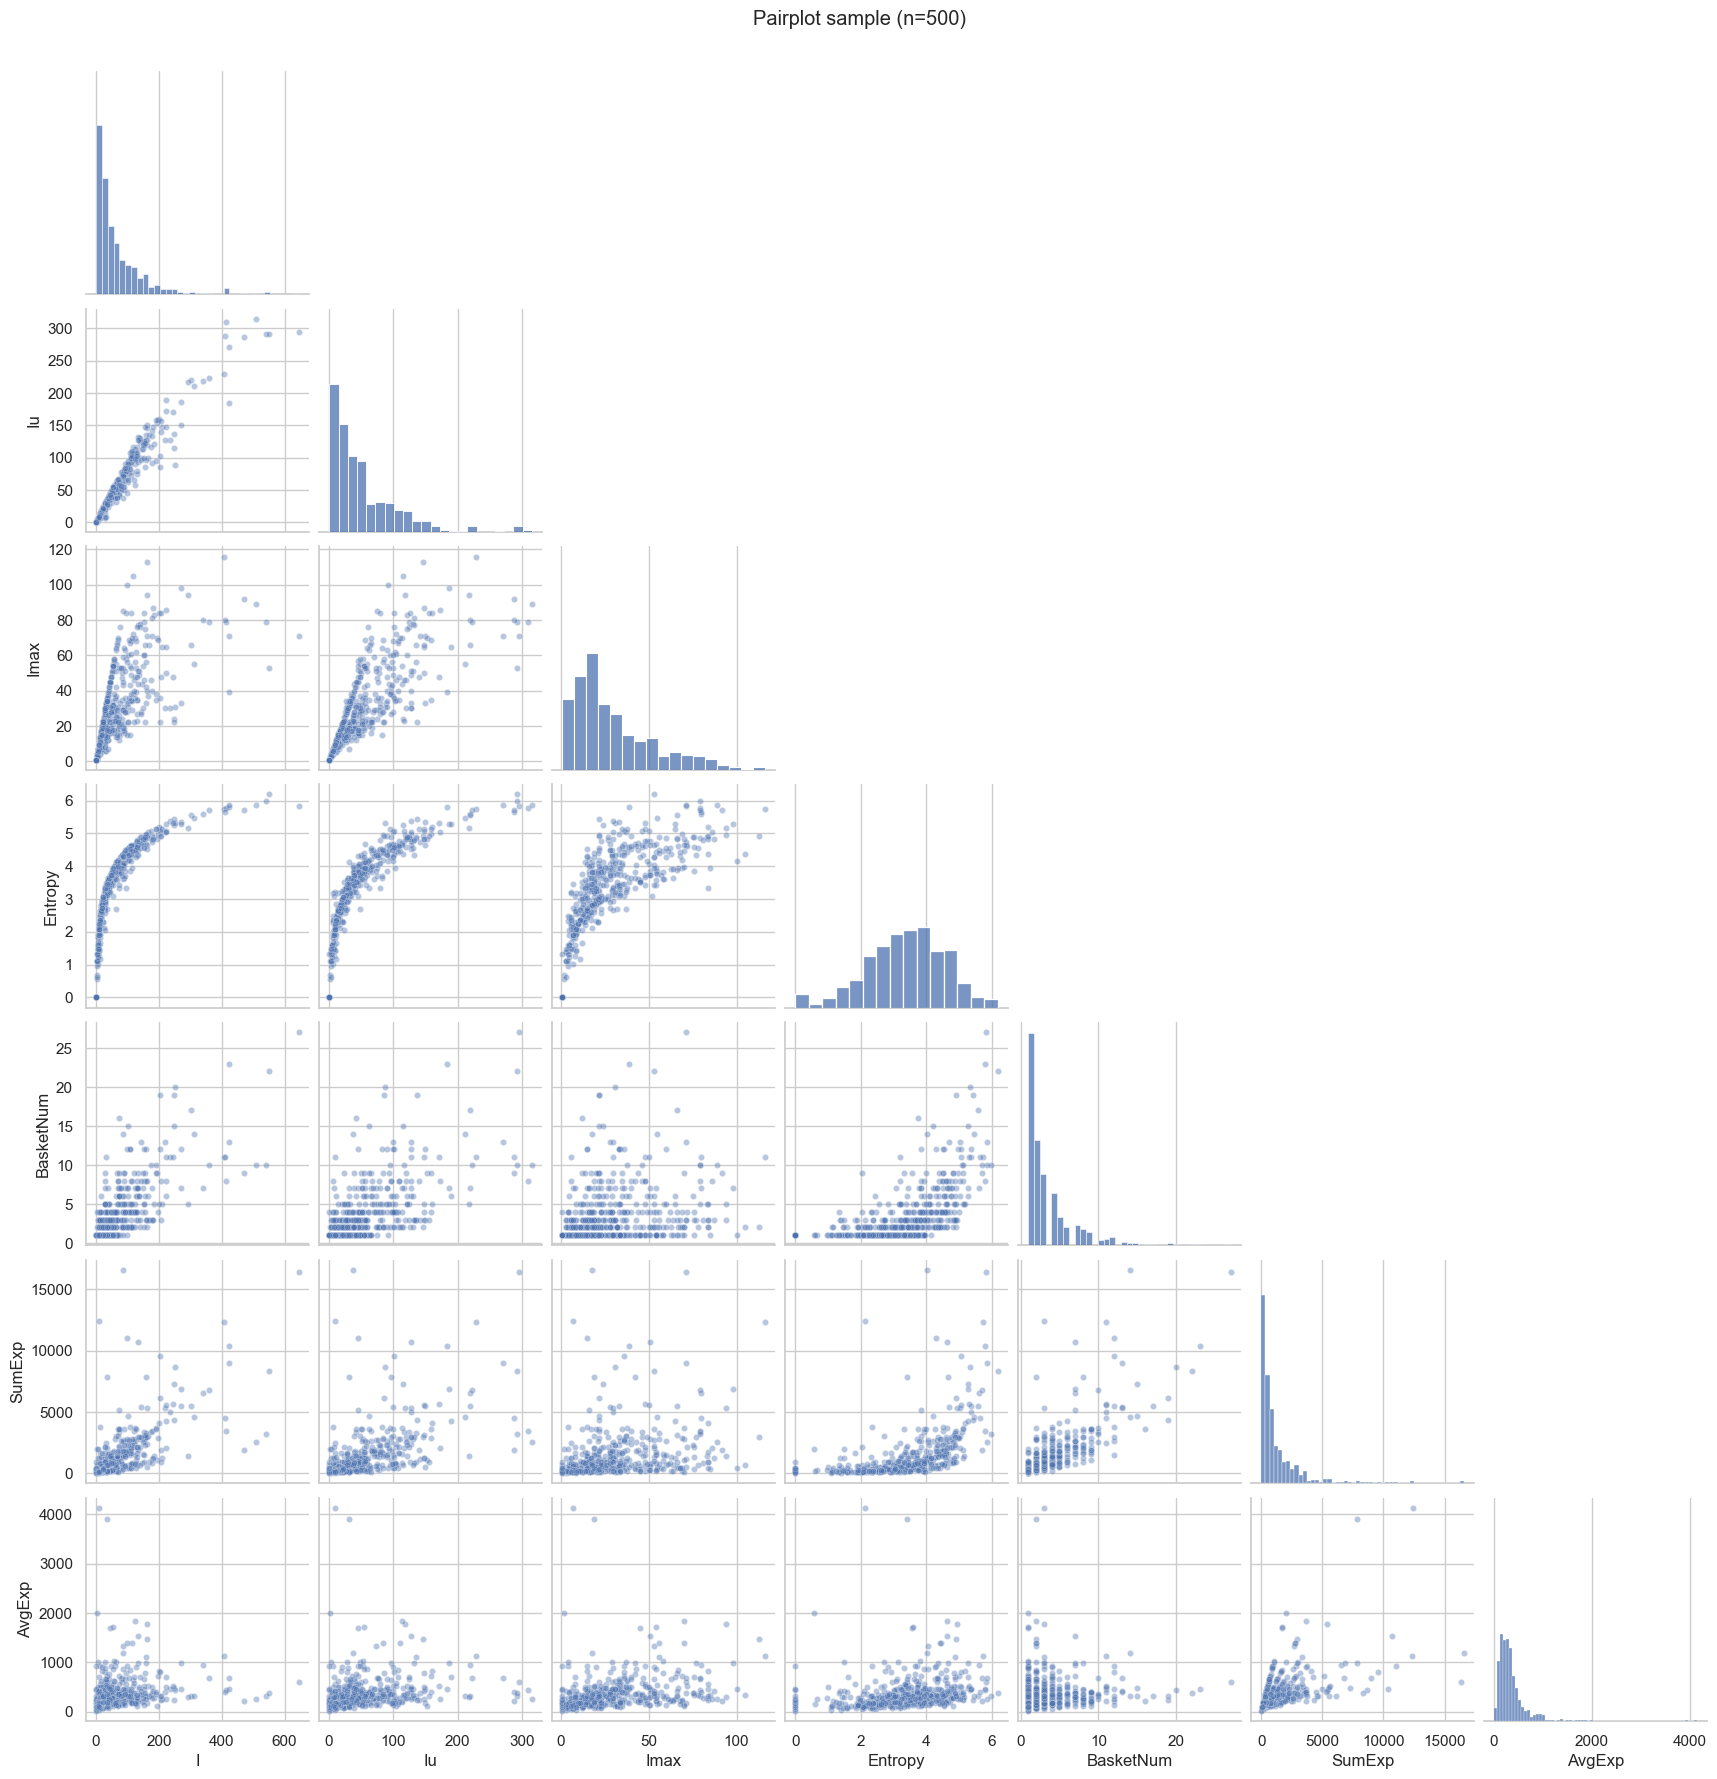

In [94]:
# Sampled pairplot (small sample to keep it fast)
sample_n = min(500, len(new_df))
pp_sample = new_df.sample(sample_n, random_state=42)
cols_to_plot = ['I','Iu','Imax','Entropy','BasketNum','SumExp','AvgExp']
_ = sns.pairplot(pp_sample[cols_to_plot], corner=True, plot_kws={'alpha':0.4, 's':20})
plt.suptitle(f'Pairplot sample (n={sample_n})', y=1.02)
plt.show()

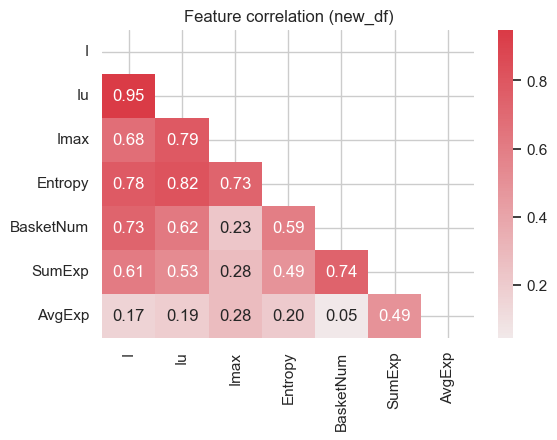

In [95]:
# Correlation heatmap
plt.figure(figsize=(6,4))
corr = new_df[cols_to_plot].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, fmt='.2f', center=0)
plt.title('Feature correlation (new_df)')
plt.show()

#### Interpretation: correlations
- **I & Iu (~0.95):** customers with many items also tend to buy many unique products (high overlap between total items and unique products).
- **Entropy & Iu / Imax (~0.8):** higher product variety and larger baskets are associated with more spread-out spending (higher entropy).
- **SumExp & BasketNum (~0.74):** total spend is more strongly driven by the number of baskets a customer has than by average basket size in this dataset.

#### Note: KMeans

KMeans results are shown below with a scatter of `I` vs `BasketNum` colored by cluster; cluster centers (based on `centers`) are displayed as black stars.

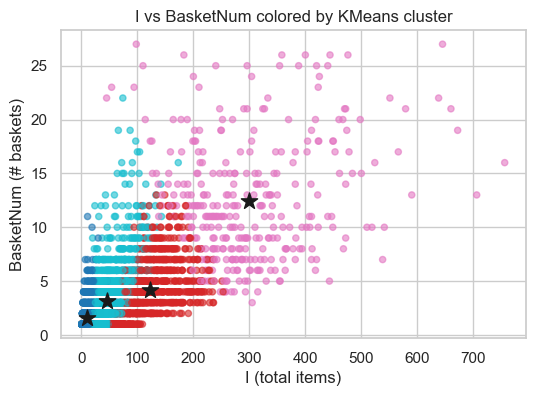

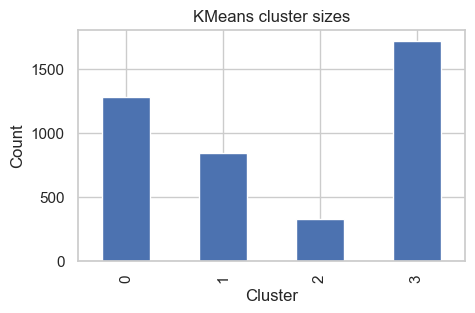

In [117]:
# Scatter plot I vs BasketNum colored by KMeans labels
cols = new_df.columns.tolist()
ix_I = cols.index('I')
ix_BasketNum = cols.index('BasketNum')
centers_xy = centers[:, [ix_I, ix_BasketNum]]
plt.figure(figsize=(6,4))
plt.scatter(new_df['I'], new_df['BasketNum'], c=kmeans.labels_, s=20, cmap='tab10', alpha=0.6)
plt.scatter(centers_xy[:,0], centers_xy[:,1], s=150, marker='*', c='k')
plt.xlabel('I (total items)')
plt.ylabel('BasketNum (# baskets)')
plt.title('I vs BasketNum colored by KMeans cluster')
plt.show()

# Bar chart of cluster sizes
import pandas as _pd
counts = _pd.Series(kmeans.labels_).value_counts().sort_index()
plt.figure(figsize=(5,3))
counts.plot(kind='bar', color='C0')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('KMeans cluster sizes')
plt.show()

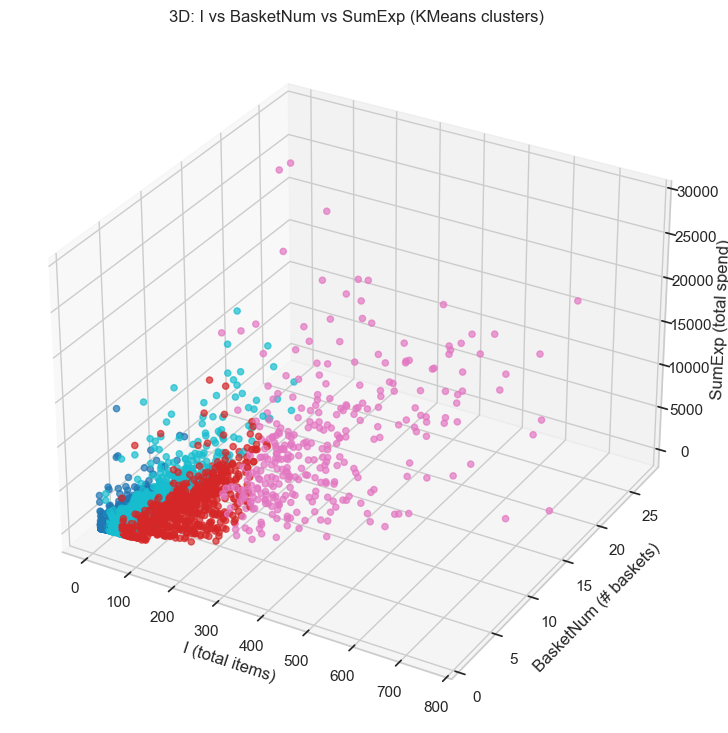

In [118]:
# 3D cluster scatter (I, BasketNum, SumExp)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(new_df['I'], new_df['BasketNum'], new_df['SumExp'], c=kmeans.labels_, marker='o', cmap=plt.cm.get_cmap('tab10'), s=20, alpha=0.7)
ax.set_xlabel('I (total items)')
ax.set_ylabel('BasketNum (# baskets)')
ax.set_zlabel('SumExp (total spend)')
plt.title('3D: I vs BasketNum vs SumExp (KMeans clusters)')
plt.show()

In [119]:
# Summarize cluster centers (numeric)
import pandas as _pd
centers_df = _pd.DataFrame(centers, columns=new_df.columns)
display(centers_df[['I','BasketNum','SumExp']].round(1))
# Identify cluster with highest SumExp
top_cluster = centers_df['SumExp'].idxmax()
print(f"Cluster {top_cluster} has the highest SumExp = {centers_df.loc[top_cluster,'SumExp']:.1f}")

,I,BasketNum,SumExp
0,10.7,1.6,396.9
1,121.8,4.1,1732.5
2,300.0,12.4,5517.0
3,46.4,3.1,1034.5


Cluster 2 has the highest SumExp = 5517.0


#### Interpretation: KMeans clusters
- The cluster with the highest total spend (SumExp) identifies the **high-value customers** (higher I and BasketNum). 
- Other clusters capture mid and low-value groups (smaller BasketNum and SumExp); compare centers above to interpret each cluster's customer profile.

These visuals help interpret cluster separation and relative sizes; use them to decide whether to adjust `n_clusters`.

### Clustering

We normalize features and run KMeans, DBSCAN and Hierarchical clustering. Visuals follow.


KMeans clusters: (array([0, 1, 2, 3], dtype=int32), array([1282,  841,  325, 1723]))


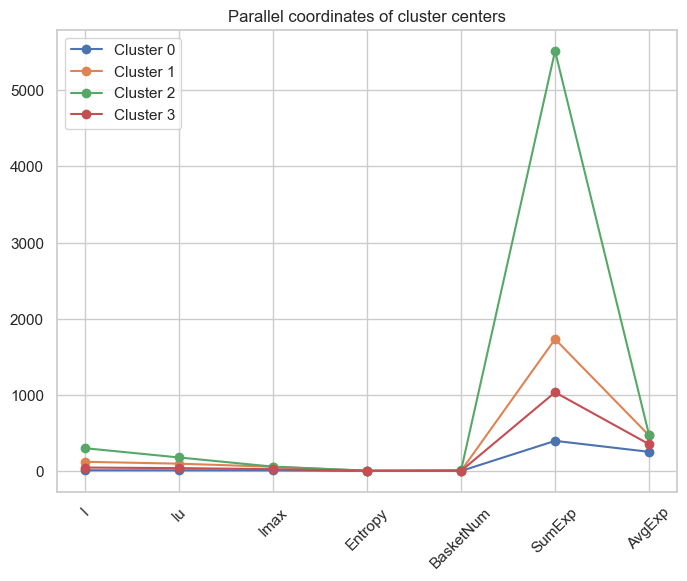

In [120]:
# Normalization
scaler = MinMaxScaler()
df_transformed = scaler.fit_transform(new_df.values)

# K-Means (fixed n_clusters = 4)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, n_init=20, max_iter=100, random_state=42)
kmeans.fit(df_transformed)
print('KMeans clusters:', np.unique(kmeans.labels_, return_counts=True))

# show cluster centers in original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(8,6))
plt.title('Parallel coordinates of cluster centers')
for i in range(len(centers)):
    plt.plot(centers[i], marker='o', label=f'Cluster {i}')
plt.xticks(range(len(new_df.columns)), new_df.columns, rotation=45)
plt.legend()
plt.show()

#### Note: KMeans

This cell scales the features and runs K-Means. The printed cluster counts show the number of customers in each cluster, and the plotted cluster centers help interpret feature patterns per cluster.

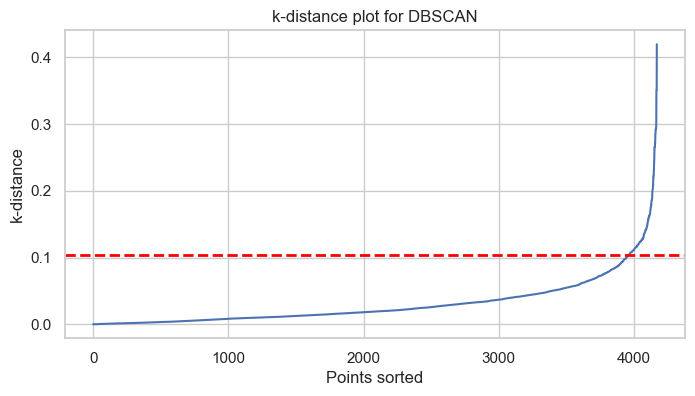

Chosen eps (95th percentile): 0.10343433119602052
DBSCAN clusters (labels and counts): (array([-1,  0]), array([ 475, 3696]))


In [137]:
# DBSCAN - use Knee method to estimate eps
min_pts = new_df.shape[1] * 2
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(df_transformed)
distances, indices = neighbors_fit.kneighbors(df_transformed)
distances = np.sort(distances[:,1])

# choose a heuristic eps (e.g., value at 95th percentile)
eps = np.percentile(distances, 95)
# Quick plot to inspect the knee
plt.figure(figsize=(8,4))
plt.plot(distances)
plt.axhline(
    y=eps,
    color='red',
    linestyle='--',
    linewidth=2,
    label='95th percentile (eps)'
)
plt.title('k-distance plot for DBSCAN')
plt.xlabel('Points sorted')
plt.ylabel('k-distance')
plt.show()

print('Chosen eps (95th percentile):', eps)

dbscan = DBSCAN(eps=eps, min_samples=min_pts)
dbscan.fit(df_transformed)
print('DBSCAN clusters (labels and counts):', np.unique(dbscan.labels_, return_counts=True))

In [122]:
# DBSCAN summary
labels, counts = np.unique(dbscan.labels_, return_counts=True)
noise_count = (dbscan.labels_ == -1).sum()
print('Labels and counts:', dict(zip(labels, counts)))
print(f'Noise points: {noise_count} ({noise_count/len(dbscan.labels_):.1%})')

Labels and counts: {np.int64(-1): np.int64(475), np.int64(0): np.int64(3696)}
Noise points: 475 (11.4%)


#### Interpretation: DBSCAN
- DBSCAN identifies dense regions and flags sparse customers as noise; the printed counts show how many clusters vs noise points were found.
- A high noise fraction suggests customers are widely dispersed and density-based clusters may be less meaningful than KMeans groups here.

#### Note: DBSCAN

This cell computes the k-distance plot used to select an `eps` heuristic (here the 95th percentile). DBSCAN then clusters customers; the printed label counts include noise (-1) and cluster sizes — use them to assess density-based structure.

### Hierarchical clustering example

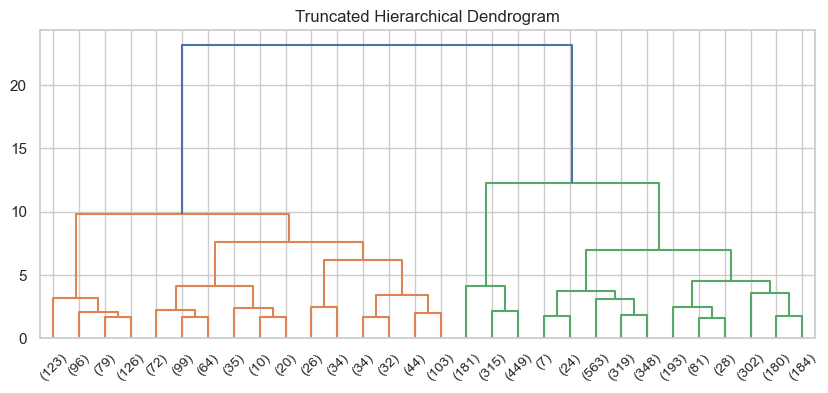

Hierarchical clusters (example counts): (array([1, 2], dtype=int32), array([ 997, 3174]))


In [123]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# create linkage and plot a truncated dendrogram
data_dist = pdist(df_transformed, metric='euclidean')
data_link = linkage(data_dist, method='ward')
plt.figure(figsize=(10,4))
dendrogram(data_link, truncate_mode='lastp', p=30)
plt.title('Truncated Hierarchical Dendrogram')
plt.show()

# cut tree at some distance to get clusters
max_d = 0.7 * np.max(data_link[:,2])
labels_h = fcluster(data_link, max_d, criterion='distance')
print('Hierarchical clusters (example counts):', np.unique(labels_h, return_counts=True))

In [124]:
# Hierarchical summary
unique_labels, counts = np.unique(labels_h, return_counts=True)
print('Number of clusters (cut):', len(unique_labels))
print('Cluster counts (example cut):', dict(zip(unique_labels, counts)))

Number of clusters (cut): 2
Cluster counts (example cut): {np.int32(1): np.int64(997), np.int32(2): np.int64(3174)}


#### Interpretation: Hierarchical clustering
- The dendrogram cut produces the number of clusters shown above (depends on cut distance); examine cluster sizes to decide whether a hierarchical cut gives meaningful segmentation compared with KMeans/DBSCAN.

#### Note: hierarchical clustering

This cell produces a truncated dendrogram (Ward linkage) and cuts the tree at a chosen distance to obtain clusters. The printed cluster counts give a sense of the hierarchical grouping at that cut-off.

## 5) Task 3: Predictive analysis (classification)

Label customers by tertiles of `SumExp` and evaluate multiple classifiers.

In [125]:
# Build classification dataset (work on a copy)
df_clf = new_df.copy()
df_clf.sort_values(by='SumExp', inplace=True)

# create Label column by tertiles
length = len(df_clf)
l1 = length // 3
l2 = l1 * 2
labels = pd.Series(index=df_clf.index, dtype='object')
labels[:] = 'low'
labels.iloc[l1:l2] = 'medium'
labels.iloc[l2:] = 'high'

# drop unused columns as in original notebook
X = df_clf.drop(columns=['Iu', 'Imax', 'SumExp', 'AvgExp'], errors='ignore')
y = labels

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
print('Train size:', len(X_train), 'Test size:', len(X_test))

Train size: 2919 Test size: 1252


#### Note: labeling & split

This cell creates `low`/`medium`/`high` labels by splitting `SumExp` into tertiles, removes unused columns for modeling, and splits the data into stratified train/test sets (70/30). Verify the reported sizes to ensure class balance in train/test samples.

In [126]:
# Helper function: Randomized grid search for classifier parameters
from scipy.stats import randint as sp_randint

def grid_search(classifier, param_distributions, x, y, n_iter=30):
    gsa = RandomizedSearchCV(classifier, param_distributions=param_distributions, n_iter=n_iter, n_jobs=4, scoring='accuracy', random_state=42)
    gsf1 = RandomizedSearchCV(classifier, param_distributions=param_distributions, n_iter=n_iter, n_jobs=4, scoring='f1_weighted', random_state=42)
    gsa.fit(x,y)
    gsf1.fit(x,y)
    dfres = pd.DataFrame(gsa.cv_results_)
    dfres.rename(columns={'mean_test_score':'accuracy'}, inplace=True)
    dfres['f1_score'] = gsf1.cv_results_['mean_test_score']
    dfres = dfres[['params','accuracy','f1_score']].sort_values(by='accuracy', ascending=False)
    print('Top parameter combos:')
    display(dfres.head())
    return gsa.best_params_

# small function to report classification performance
def report_scores(clf, X_train, y_train, X_test, y_test, show_feat=True):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print('Classification report:')
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return clf, y_pred

#### Note: model helpers

`grid_search` uses RandomizedSearchCV to tune hyperparameters (accuracy and f1_weighted) and returns the best combination. `report_scores` trains a classifier, prints the classification report, and displays a confusion matrix for easy inspection of errors.

### Naive Bayes

Classification report:
              precision    recall  f1-score   support

        high       0.87      0.69      0.77       418
         low       0.67      0.86      0.75       417
      medium       0.55      0.51      0.53       417

    accuracy                           0.69      1252
   macro avg       0.70      0.69      0.68      1252
weighted avg       0.70      0.69      0.68      1252



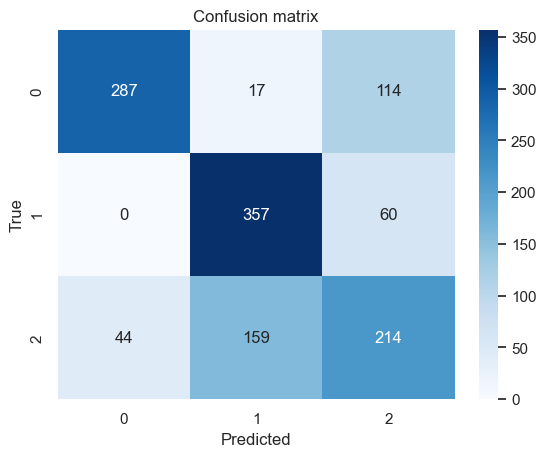

In [127]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb, y_pred_gnb = report_scores(gnb, X_train, y_train, X_test, y_test, show_feat=False)

In [128]:
# Naive Bayes performance summary (numeric)
from sklearn.metrics import accuracy_score, f1_score
acc = accuracy_score(y_test, y_pred_gnb)
f1 = f1_score(y_test, y_pred_gnb, average='weighted')
print('Accuracy:', round(acc, 3))
print('Weighted F1:', round(f1, 3))

Accuracy: 0.685
Weighted F1: 0.683


#### Note: Naive Bayes

Gaussian Naive Bayes is trained and evaluated; check the printed classification report for per-class precision/recall/F1 and the confusion matrix to see common misclassifications (e.g., medium vs high).

### Decision Tree (Randomized Search)

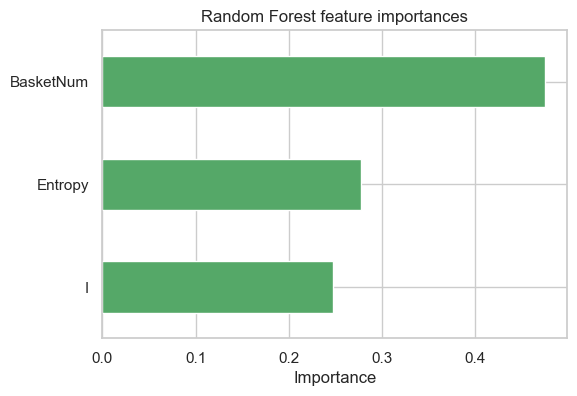

In [129]:
# Random Forest feature importance (if available)
if hasattr(rf, 'feature_importances_'):
    feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
    plt.figure(figsize=(6,4))
    feat_imp.plot(kind='barh', color='C2')
    plt.title('Random Forest feature importances')
    plt.xlabel('Importance')
    plt.show()
else:
    print('Random Forest model does not expose feature_importances_')

Feature importances show which variables the Random Forest used most for prediction; interpret them together with other model metrics.

Top parameter combos:


,params,accuracy,f1_score
19,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.749223,0.749393
7,"{'criterion': 'gini', 'max_depth': 4, 'min_sam...",0.747183,0.747961
6,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.746487,0.746904
17,"{'criterion': 'entropy', 'max_depth': 9, 'min_...",0.744773,0.744295
0,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.744439,0.741977


Classification report:
              precision    recall  f1-score   support

        high       0.81      0.77      0.79       418
         low       0.73      0.83      0.78       417
      medium       0.64      0.59      0.61       417

    accuracy                           0.73      1252
   macro avg       0.73      0.73      0.73      1252
weighted avg       0.73      0.73      0.73      1252



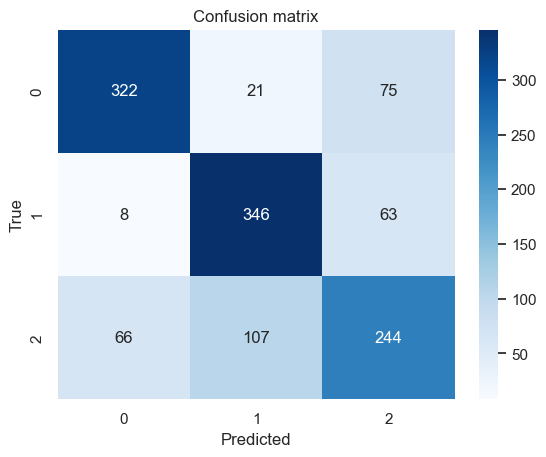

In [130]:
from sklearn.tree import DecisionTreeClassifier
param_dist = {"max_depth": [2,3,4,5,6,7,8,9,10,None],
              "min_samples_split": sp_randint(3, 30),
              "min_samples_leaf": sp_randint(1, 40),
              "criterion": ["entropy", "gini"],
              "splitter": ["best", "random"]}

clf = DecisionTreeClassifier(random_state=42)
best_params = grid_search(clf, param_dist, X_train, y_train, n_iter=20)

dt = DecisionTreeClassifier(**best_params, random_state=42)
dt, y_pred_dt = report_scores(dt, X_train, y_train, X_test, y_test)

#### Note: Decision Tree

RandomizedSearchCV explores Decision Tree hyperparameters (depth, splits, criterion). The selected `best_params` are used to train the final tree and the classification report + confusion matrix summarise model performance.

### Random Forest (Randomized Search)

Top parameter combos:


,params,accuracy,f1_score
14,"{'bootstrap': True, 'class_weight': None, 'cri...",0.758478,0.758986
0,"{'bootstrap': True, 'class_weight': None, 'cri...",0.756080,0.757179
13,"{'bootstrap': True, 'class_weight': None, 'cri...",0.755736,0.756482
2,"{'bootstrap': False, 'class_weight': None, 'cr...",0.754711,0.755267
15,"{'bootstrap': True, 'class_weight': 'balanced'...",0.754711,0.755202


Classification report:
              precision    recall  f1-score   support

        high       0.83      0.78      0.81       418
         low       0.77      0.83      0.80       417
      medium       0.66      0.64      0.65       417

    accuracy                           0.75      1252
   macro avg       0.75      0.75      0.75      1252
weighted avg       0.75      0.75      0.75      1252



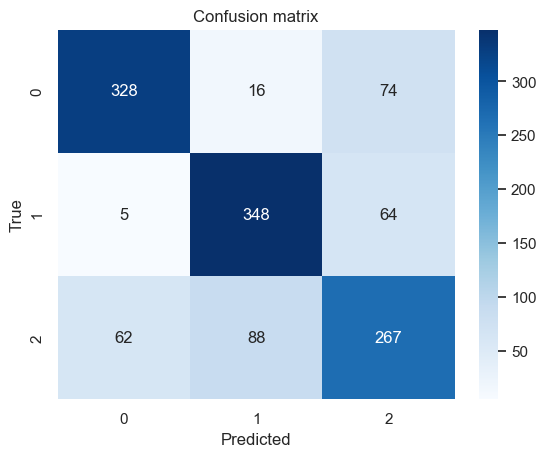

In [131]:
from sklearn.ensemble import RandomForestClassifier
param_dist = {"n_estimators": [30,50,100],
              "max_depth": [2,4,6,8,None],
              "max_features": sp_randint(1, X_train.shape[1] + 1),
              "min_samples_split": sp_randint(2, 20),
              "min_samples_leaf": sp_randint(1, 20),
              "bootstrap": [True, False],
              "criterion": ["gini", "entropy"],
              "class_weight": ['balanced', None]}

clf = RandomForestClassifier(random_state=42)
best_params = grid_search(clf, param_dist, X_train, y_train, n_iter=20)

rf = RandomForestClassifier(**best_params, random_state=42)
rf, y_pred_rf = report_scores(rf, X_train, y_train, X_test, y_test)

In [132]:
# Random Forest: top features (numeric)
if hasattr(rf, 'feature_importances_'):
    feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print('Top features:')
    display(feat_imp.head(5).round(3))
else:
    print('Random Forest importance not available')

Top features:


BasketNum    0.475
Entropy      0.278
I            0.247
dtype: float64

#### Interpretation: Random Forest
- The Random Forest top features (above) indicate which customer attributes drive the `SumExp` classification (features with higher importance are the main signals the model uses). 
- Use these features to guide business actions or further feature engineering (e.g., focus on BasketNum or I if they rank highest).

#### Note: Random Forest

RandomizedSearchCV explores Random Forest hyperparameters (estimators, max_depth, features, etc.). The best configuration is trained and evaluated; compare its metrics with other models to select the most suitable approach.

### KNN (choose k by simple search)

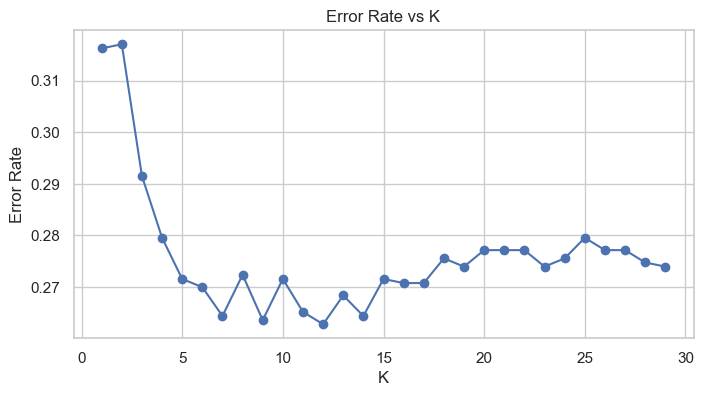

Best k (by error rate): 12
Classification report:
              precision    recall  f1-score   support

        high       0.79      0.79      0.79       418
         low       0.76      0.83      0.79       417
      medium       0.66      0.59      0.62       417

    accuracy                           0.74      1252
   macro avg       0.73      0.74      0.73      1252
weighted avg       0.73      0.74      0.73      1252



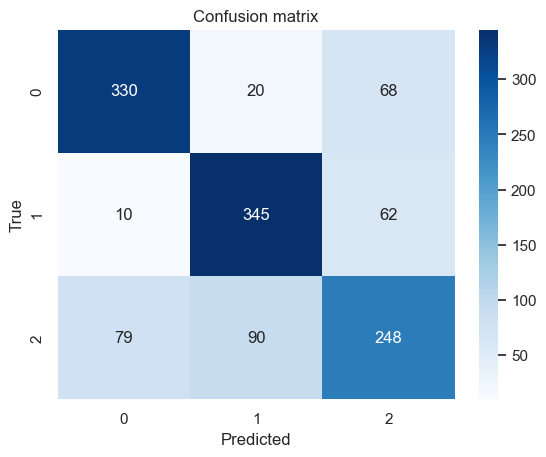

In [133]:
from sklearn.neighbors import KNeighborsClassifier

error_rate = []
max_i = 30
for i in range(1, max_i):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(8,4))
plt.plot(range(1,max_i), error_rate, marker='o')
plt.title('Error Rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

best_k = np.argmin(error_rate) + 1
print('Best k (by error rate):', best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn, y_pred_knn = report_scores(knn, X_train, y_train, X_test, y_test, show_feat=False)

#### Interpretation: KNN
- The error-rate plot chosen `k = {}` shows the best balance between bias/variance for this dataset.
- Smaller `k` may overfit, larger `k` may underfit; review the error curve above to confirm the selected `k` is near the minimum.

#### Note: KNN

This cell plots error rate vs `k` to help select the best number of neighbors; after choosing `k` the final KNN model is evaluated and metrics are shown for comparison with other classifiers.

### SVM (Randomized Search over kernel)

Top parameter combos:


,params,accuracy,f1_score
0,{'kernel': 'linear'},0.726966,0.725987
2,{'kernel': 'rbf'},0.697500,0.696722
3,{'kernel': 'sigmoid'},0.582046,0.574092
1,{'kernel': 'poly'},0.567662,0.545892


Classification report:
              precision    recall  f1-score   support

        high       0.83      0.78      0.81       418
         low       0.73      0.80      0.76       417
      medium       0.60      0.58      0.59       417

    accuracy                           0.72      1252
   macro avg       0.72      0.72      0.72      1252
weighted avg       0.72      0.72      0.72      1252



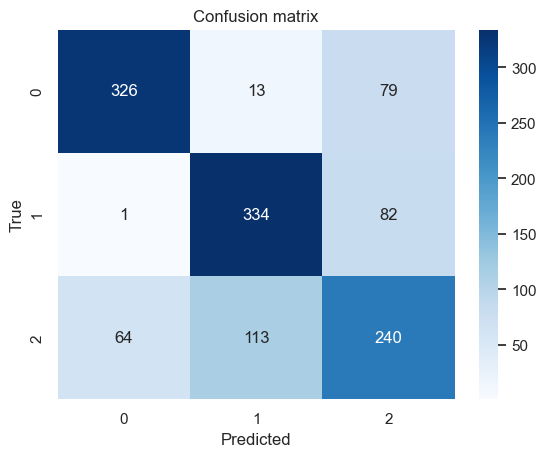

In [134]:
from sklearn.svm import SVC
param_dist = {"kernel": ['linear', 'poly', 'rbf', 'sigmoid']}
clf = SVC(random_state=42)
best_params = grid_search(clf, param_dist, X_train, y_train, n_iter=10)

svm = SVC(**best_params, random_state=42)
svm, y_pred_svm = report_scores(svm, X_train, y_train, X_test, y_test, show_feat=False)

#### Note: SVM

A randomized search over kernels is used to select a candidate SVM; after training, review the classification report and confusion matrix to assess how SVM performs relative to other models.

## 9) Results: summaries & plots

We summarize the main outputs: feature distributions, cluster sizes, classification performance summary.

<Figure size 1000x600 with 0 Axes>

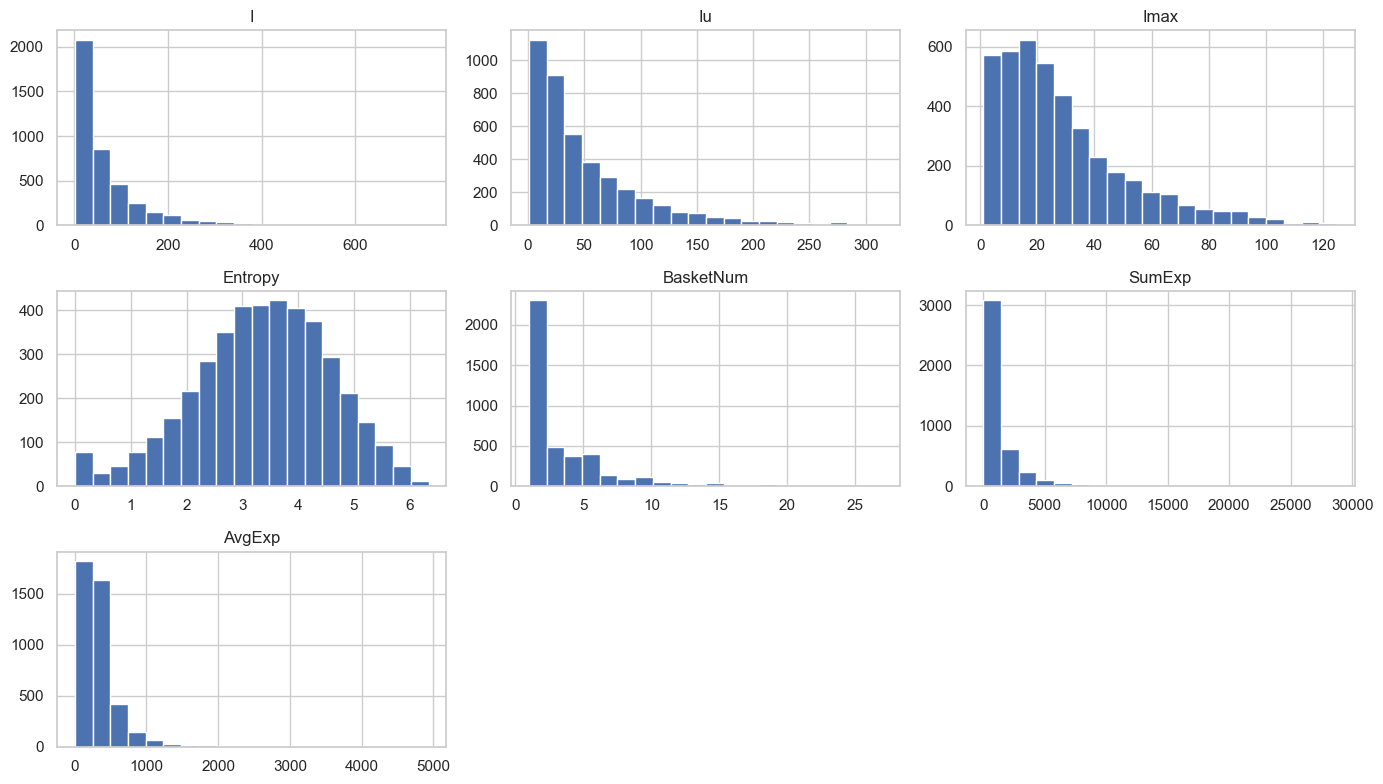

KMeans cluster counts: (array([0, 1, 2, 3], dtype=int32), array([1282,  841,  325, 1723]))


In [135]:
# feature distributions
plt.figure(figsize=(10,6))
new_df[['I','Iu','Imax','Entropy','BasketNum','SumExp','AvgExp']].hist(bins=20, figsize=(14,8))
plt.tight_layout()
plt.show()

# show top cluster sizes
print('KMeans cluster counts:', np.unique(kmeans.labels_, return_counts=True))


#### Note: results

This cell visualizes distributions of computed features and reports KMeans cluster counts. 

## 10) Tests & assertions

Small sanity checks to validate that each task's key outcomes are met.

In [136]:
# Basic assertions
assert df['CustomerID'].notnull().all(), 'There are still missing CustomerID values'
assert (df['Qta'] >= 0).all(), 'There are negative quantities remaining'
assert 'Amount' in df.columns, 'Amount column missing'
assert new_df.shape[0] > 0, 'No customers left after outlier removal'

print('All basic assertions passed.')

All basic assertions passed.


#### Note: sanity checks

These assertions validate basic invariants (no missing `CustomerID`, non-negative `Qta`, presence of `Amount`, and that `new_df` contains customers). If assertions pass, the dataset is consistent for further analysis.